# NUMERICAL EXPERIMENTS "Personalized Federated Learning via Active Sampling"

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

plt.rcParams.update({'axes.spines.right': False,
                     'axes.spines.top': False})

## A. Toy Datasets

Each local dataset $D^{(i)}$ consists of $m_i$ realizations of i.i.d. random variables with a common probability distribution $p^{(i)}$ (Eq.(9)).

Each data point is characterized by a feature vector $\mathbf{x}^{(i,r)} \in R^d$ and a scalar label $y^{(i,r)}$, for $r = 1,...,m_i$. It would be convenient to stack the feature vectors and labels of a local dataset $D^{(i)}$, into a feature matrix and label vector, respectively (see Eq.(10)).

The feature vectors $\mathbf{x}^{(i,r)} ∼ N(0,I_{d×d})$, are drawn i.i.d. from a standard multivariate normal distribution. The labels $y^{(i,r)}$ of the data points are modeled as a noisy linear combination of the corresponding features $\mathbf{x}^{(i,r)}$ (see Eq.(11)).

The noise $\epsilon^{(i)} ∼ N(0,I)$, for $i ∈ V$ and $r = 1,...,m_i$, are i.i.d. realizations of a standard normal distribution. The noise variance $\sigma^2 ≥ 0$ in (Eq. (11)) is assumed fixed.

In [2]:
def gen_ds(n_clusters, n_ds, n_samples, n_features, noise_scale=1.0):
    
    """
    
    Function to create noisy Gaussian regression datasets multivar Gaussian ~N(0,I). 
    Datasets within the cluster share the same true weight vector. 
    For each node we create training (size = n_samples) and validation (size = 100) ds.
    
    Args:
    : n_clusters  : int, number of clusters
    : n_ds        : list of len(n_clusters), number of local datasets per cluster 
    : n_samples   : number of samples in a local dataset
    : n_features  : number of features of a datapoint
    : noise_scale : scale of normal distribution used to generate data noise
    
    Out:
    : ds_train       : tuple (X_train, y_train), where X array of shape (n_nodes, m_i, d) and y - (n_nodes, m_i, 1)
    : ds_val         : tuple (X_val ,y_val), where X array of shape (n_nodes, m_i, d) and y - (n_nodes, m_i, 1)
    : cluster_labels : list of len(n_ds) cluster assignments for each local dataset 
    : true_weights   : array of shape (n_clusters, n_features), true weight vector for each cluster

    """
    
    # Lists to store and return outputs

    cluster_labels = []
    m_val = 500 # hardcoded size of the validation set
    n_nodes = sum(n_ds)
    X_train, y_train = np.zeros((n_nodes, n_samples, n_features)), np.zeros((n_nodes, n_samples, 1))
    X_val, y_val = np.zeros((n_nodes, m_val, n_features)), np.zeros((n_nodes, m_val, 1))
    
    true_weights   = np.zeros((n_clusters, n_features))

    node_id = 0
    for i in range(n_clusters):
    
        # Sample true weight vector for cluster i
        #w = np.random.normal(0, 1, size=(n_features,1))
        w = np.random.uniform(-5, 5, size=(n_features,1))
        true_weights[i] = w.reshape(-1,)

        for j in range(n_ds[i]):
            # Sample datapoints from multivar Gaussian ~N(0,I)
            X = np.random.normal(0, 1.0, size=(n_samples + m_val, n_features))
            
            # Sample noise 
            noise = np.random.normal(loc=0.0, scale=noise_scale, size=(n_samples + m_val, 1))
            
            # Noisy Gaussian regression
            y = X@w + noise

            # Split train vs val
            X_t, X_v, y_t, y_v = train_test_split(X, y, train_size=n_samples, test_size=m_val)
            X_train[node_id] = X_t
            y_train[node_id] = y_t
            
            X_val[node_id] = X_v
            y_val[node_id] = y_v
            
            # ds_train.append( (X_train, y_train) )
            # ds_val.append( (X_val, y_val) )
            
            cluster_labels.append(i)
            node_id += 1

    return (X_train, y_train), (X_val, y_val), cluster_labels, true_weights

## Configuration

In [3]:
def create_aug_ds(local_ds, X_test, h_hat, eta):

    """
    Function to create augmented dataset, i.e. local dataset stacked with global test set (D^(t), h_hat(D^(t))), 
    see Eq.(6).
    
    Arg:
    : local_ds : tuple of two arrays (X,y) of shapes X (m_i, d), y (m_i, 1)
    : X_test   : array of shape (m_test, d)
    : h_hat    : sklrean model instance
    : eta      : scalar, sample weight for test datapoints

    Out:
    : X_aug         : array of shape (m_i + m_i_test, d), augmented dataset
    : y_aug         : array of shape (m_i + m_i_test), augmented dataset
    : sample_weight : array of shape (m_i + m_i_test,), sample weights for sklearn model
    
    """

    X, y = local_ds[0], local_ds[1]
    y_test = h_hat.predict(X_test)
    
    # Construct augmented dataset
    X_aug = np.concatenate((X, X_test), axis=0)
    y_aug = np.concatenate((y, y_test.reshape(-1,1)), axis=0)
    
    # Set sample weights
    m, m_test = y.shape[0], y_test.shape[0]
    sample_weight = np.concatenate((np.ones((m,)), np.ones((m_test,))*eta))   
    
    return X_aug, y_aug, sample_weight

In [8]:
def get_oracle(Xs, ys, cluster_ids, oracle_model):
    
    """
    Function which takes in local datasets and untrained model and 
    returns a model fit to pooled local datasets with cluster label = 0.
    
    Args:

    : Xs and ys    : arrays, local datasets D^(i'). Xs shape (n_clients, m_i, d); ys shape (n_clients, m_i, 1)
    : cluster_ids  : array of shape (n_clients,), cluster labels
    : oracle_model : sklrean model instance
    
    Out:
    : oracle_model : sklrean model instance fit to the local datasets with cluster label = 0 (1st cluster).
    
    """

    m_i, d = Xs[0].shape[0], Xs[0].shape[1]
    # find indices of clients from 1st cluster
    idx = np.where(np.array(cluster_ids) == 0)[0]
    X, y = Xs[idx].reshape(-1, d), ys[idx].reshape(-1,)
    oracle_model.fit(X, y)
    
    return oracle_model

In [36]:
def train(ds_train, ds_val, cluster_ids, S, sigma, R, eta, **kwargs):

    """
    
    Function to create datasets and implement Algorithm 1  "PersFL for Parametric Models".
    
    Args:
    
    : n_clusters : scalar, number of disjoint clusters
    : m_i        : scalar, sample size of the datasets. We asssume same `m_i` for all datasets.
    : d          : scalar, dimention of the feature vector
    : S          : scalar, size of randomly chosen subset of the clients
    : sigma      : scalar, noise scale, see Eq.(11)
    : R          : scalar, number of iterations
    : eta        : scaling param, scalar, see Eq.(7)
    : n_i       : scalar, number of datasets in a cluster (used if `regenerate=False`)
    : **kwargs   : key args to pass to sklearn model
    
    Out:

    : losses     : array of len (R), loss values on each iteration given by the best candidate, 
                   Eq.(8) l_i0 in the paper

    """

    X_train, y_train = ds_train[0], ds_train[1]
    X_val, y_val = ds_val[0], ds_val[1]

    n_clients = len(X_train)

    # Shared dataset   
    X_test = np.random.normal(0, 1.0, size=(100, X_train[0].shape[1]))

    models = [DecisionTreeRegressor(**kwargs).fit(X_train[n], y_train[n].reshape(-1,)) for n in range(n_clients)]

    loss_R = np.zeros((n_clients, R))
    for itr in range(R):
        for n in range(n_clients):
            pool = np.concatenate([np.arange(n), np.arange(n+1, n_clients)])
            idx = np.random.choice(pool, S, replace=False)

            subset = (X_train[idx], y_train[idx])
            models_candidates = [DecisionTreeRegressor(**kwargs) for i in range(S)]
            loss = np.zeros((S))
            for k in range(S):
                # get augmented dataset
                X_aug, y_aug, sample_weight = create_aug_ds((subset[0][k], subset[1][k]), X_test, models[n], eta)
    
                # fit model to aug dataset                   
                models_candidates[k].fit(X_aug, y_aug.reshape(-1,), sample_weight=sample_weight)
        
                # compute loss on D_(1) training subset
                preds = models_candidates[k].predict(X_train[n])
                loss[k] = np.mean((y_train[n] - preds.reshape(-1,1))**2)
            
            # determine candidate with a smallest D1 training loss
            candidate_idx = np.argmin(loss)
            models[n] = models_candidates[candidate_idx]
            
        for n in range(n_clients):
            preds_val = models[n].predict(X_val[n])
            loss_R[n, itr] = np.mean((y_val[n].reshape(-1,1) - preds_val.reshape(-1,1))**2)
    return np.mean(loss_R, axis=0)
    

In [5]:
def MSE_params(pred, target, model=None, extra=None):
    # we expect linear model here
    return torch.mean((pred - target) ** 2)

## F. Training a Personalized Decision Tree (Figure 7)

### Different d/m ratio (noise=0, S=20)

In [54]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50]*3       # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
dims       = [2]    # d, dimentionality of the feature vector
eta        = 0.05        # learning rate
R          = 200        # n.o. iterations
sigma      = 0           # noise
S          = 30          # batch size
reps       = 10        # repeatitions of the experiment 

In [55]:
%%time
def experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S, **kwargs):

    params_len = len(dims)
    mse = np.zeros((params_len, R))
    
    for i, d in enumerate(dims):
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i] = train(ds_train, ds_val, cluster_labels, S, sigma, R, eta, **kwargs)
    return mse

mse_reps  = np.zeros((reps, len(dims), R))
baselines_reps = np.zeros((reps, len(dims)))
loss_aggr_reps = np.zeros((reps, len(dims)))

for r in range(reps):
   mse_reps[r] = experiment(n_clusters, n_i, m_i, dims, eta, R, sigma, S, max_depth=5)
    

CPU times: user 39min 16s, sys: 4.37 s, total: 39min 20s
Wall time: 39min 26s


In [56]:
mse_reps.shape

(10, 1, 200)

In [57]:
# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)

sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)

In [58]:
mean_mse[0]

array([5.67384764, 5.52299051, 5.43095093, 5.32314193, 5.27704294,
       5.20795925, 5.17800914, 5.07341667, 5.03066094, 5.01769168,
       4.96447126, 4.94628045, 4.91080724, 4.88453283, 4.84457562,
       4.80317282, 4.81197142, 4.79380264, 4.74428155, 4.7482874 ,
       4.72485401, 4.71995648, 4.68002199, 4.70065111, 4.67279256,
       4.66876813, 4.65309287, 4.64011485, 4.63308417, 4.63178369,
       4.62915281, 4.60946245, 4.61181607, 4.60280897, 4.61229626,
       4.60832866, 4.57453895, 4.57107093, 4.5671798 , 4.56170202,
       4.53367558, 4.56708573, 4.55674629, 4.55738707, 4.54705131,
       4.53748428, 4.52517611, 4.53744475, 4.53178394, 4.51851237,
       4.52277123, 4.50333509, 4.5163733 , 4.50963703, 4.49700989,
       4.48856402, 4.4910225 , 4.49149262, 4.49033069, 4.48794957,
       4.48481495, 4.48297905, 4.47006769, 4.46722796, 4.47718908,
       4.47297901, 4.45289808, 4.44674093, 4.46403727, 4.45363729,
       4.44616413, 4.45507346, 4.45416699, 4.46350131, 4.46369

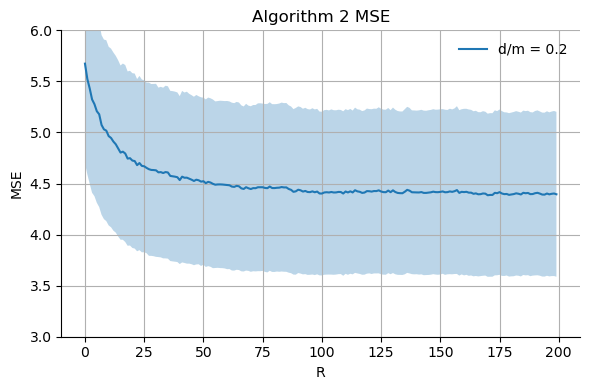

In [60]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(1):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    plt.axhline(y = mean_mse_baseline[i], ls='--')
    plt.axhline(y = mean_mse_aggr[i], ls='dotted')
  
plt.xlabel('R')
plt.ylabel('MSE')
# plt.yscale('log')
plt.ylim(3,6)
plt.legend(frameon=False)
plt.title('Algorithm 2 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

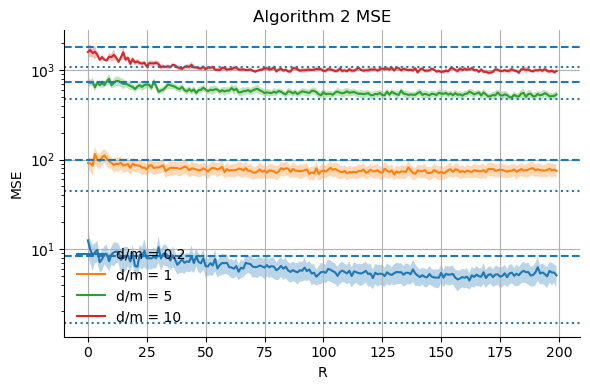

In [48]:
# Plot with shaded error bars (mean ± SEM)
labels = ['d/m = 0.2', 'd/m = 1', 'd/m = 5', 'd/m = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(dims)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    plt.axhline(y = mean_mse_baseline[i], ls='--')
    plt.axhline(y = mean_mse_aggr[i], ls='dotted')
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 2 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
if save_data:
    df = pd.DataFrame(data=mean_mse.T)
    df.to_csv('Algo_2_mean_mse.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_baseline, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_baseline.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_aggr, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_aggr.csv', mode='a', index=True, header=None)

### Noise

In [58]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
d          = 50
sigmas     = [0, 1.0, 10]     
eta        = 0.05        # learning rate
R          = 200        # n.o. iterations
S          = 20          # batch size
reps       = 10          # repeatitions of the experiment 

In [59]:
%%time
def experiment(n_clusters, n_i, m_i, d, eta, R, sigmas, S, **kwargs):

    params_len = len(sigmas)
    mse = np.zeros((params_len, R))
    baselines = np.zeros((params_len))
    loss_aggr = np.zeros((params_len))
    
    for i, sigma in enumerate(sigmas):
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], baselines[i], loss_aggr[i] = train(ds_train, ds_val, cluster_labels, S, sigma, R, eta, **kwargs)
    return mse, baselines, loss_aggr

mse_reps  = np.zeros((reps, len(sigmas), R))
baselines_reps = np.zeros((reps, len(sigmas)))
loss_aggr_reps = np.zeros((reps, len(sigmas)))

for r in range(reps):
   mse_reps[r], baselines_reps[r], loss_aggr_reps[r] = experiment(n_clusters, n_i, m_i, d, eta, R, sigmas, S, max_depth=5)
    

CPU times: user 2min 29s, sys: 383 ms, total: 2min 29s
Wall time: 2min 30s


In [60]:
# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
mean_mse_baseline = np.mean(baselines_reps, axis=0)
mean_mse_aggr = np.mean(loss_aggr_reps, axis=0)

sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)
sem_bl  = np.std(mean_mse_baseline, axis=0, ddof=1) / np.sqrt(reps)
sem_aggr  = np.std(mean_mse_aggr, axis=0, ddof=1) / np.sqrt(reps)

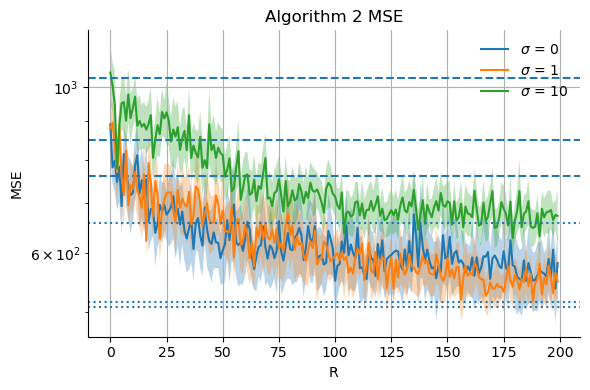

In [62]:
# Plot with shaded error bars (mean ± SEM)
labels = [r'$\sigma$ = 0', r'$\sigma$ = 1', r'$\sigma$ = 10']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(sigmas)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    plt.axhline(y = mean_mse_baseline[i], ls='--')
    plt.axhline(y = mean_mse_aggr[i], ls='dotted')
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 2 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
if save_data:
    df = pd.DataFrame(data=mean_mse.T)
    df.to_csv('Algo_2_mean_mse_noise.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_baseline, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_baseline_noise.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_aggr, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_aggr_noise.csv', mode='a', index=True, header=None)

### Subset size

In [76]:
#----------------Balanced clustered dataset (|C_1|=|C_2|=50)---------------------#
n_clusters = 2           # n.o. clusters 
n_i        = [50, 50]    # n.o. local datasets per cluster
m_i        = 10          # n.o. samples in local dataset
d          = 50   
eta        = 0.05        # learning rate
R          = 200        # n.o. iterations
sigma      = 0           # noise
Ss         = [5, 10, 30]    # batch size
reps       = 10          # repeatitions of the experiment 

In [77]:
%%time
def experiment(n_clusters, n_i, m_i, d, eta, R, sigma, Ss, **kwargs):

    params_len = len(Ss)
    mse = np.zeros((params_len, R))
    baselines = np.zeros((params_len))
    loss_aggr = np.zeros((params_len))
    
    for i, S in enumerate(Ss):
        ds_train, ds_val, cluster_labels, true_weights = gen_ds(n_clusters, n_i, m_i, d, sigma)
        mse[i], baselines[i], loss_aggr[i] = train(ds_train, ds_val, cluster_labels, S, sigma, R, eta, **kwargs)
    return mse, baselines, loss_aggr

mse_reps  = np.zeros((reps, len(Ss), R))
baselines_reps = np.zeros((reps, len(Ss)))
loss_aggr_reps = np.zeros((reps, len(Ss)))

for r in range(reps):
   mse_reps[r], baselines_reps[r], loss_aggr_reps[r] = experiment(n_clusters, n_i, m_i, d, eta, R, sigma, Ss, max_depth=5)
    

CPU times: user 1min 55s, sys: 250 ms, total: 1min 55s
Wall time: 1min 55s


In [78]:
# Compute mean and SEM across reps
mean_mse = np.mean(mse_reps, axis=0)
mean_mse_baseline = np.mean(baselines_reps, axis=0)
mean_mse_aggr = np.mean(loss_aggr_reps, axis=0)

sem_mse  = np.std(mse_reps, axis=0, ddof=1) / np.sqrt(reps)
sem_bl  = np.std(mean_mse_baseline, axis=0, ddof=1) / np.sqrt(reps)
sem_aggr  = np.std(mean_mse_aggr, axis=0, ddof=1) / np.sqrt(reps)

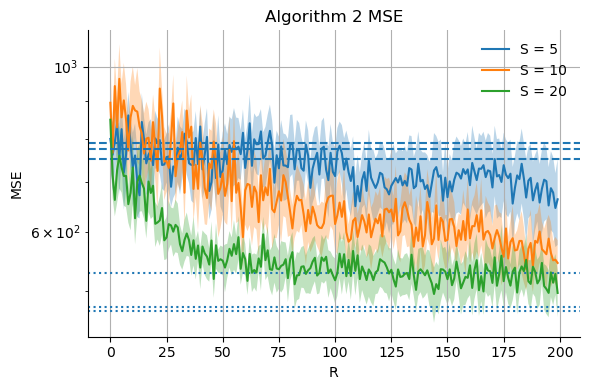

In [79]:
# Plot with shaded error bars (mean ± SEM)
labels = ['S = 5', 'S = 10', 'S = 20', 'S = 30']
plt.figure(figsize=(6, 4))
x = np.arange(R)

for i in range(len(Ss)):
    plt.plot(x, mean_mse[i], label=labels[i])
    plt.fill_between(x, mean_mse[i] - sem_mse[i], mean_mse[i] + sem_mse[i], alpha=0.3)
    plt.axhline(y = mean_mse_baseline[i], ls='--')
    plt.axhline(y = mean_mse_aggr[i], ls='dotted')
  
plt.xlabel('R')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend(frameon=False)
plt.title('Algorithm 2 MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
if save_data:
    df = pd.DataFrame(data=mean_mse.T)
    df.to_csv('Algo_2_mean_mse_S.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_baseline, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_baseline_S.csv', mode='a', index=True, header=None)

    df = pd.DataFrame(data=np.tile(mean_mse_aggr, [2,]).reshape(2,-1))
    df[5] = [-10,210]
    df = df.set_index(5)
    df.to_csv('Algo_2_mean_mse_aggr_S.csv', mode='a', index=True, header=None)

### Different sample weight (regularization term), noise=0, S=20, d/m=2

In [ ]:
# def experiment(n_clusters, n_i, m_i, regenerate=False, **kwargs):
#     # other params of experiment
#     R     = 500
#     d     = 20
#     sigma = 0
#     S     = 20
    
#     # try out different reg.term / sample weight
#     etas = [0, 1, 10, 50]
#     cs = ['b', 'g', 'r', 'c']
    
#     params_len = len(etas)
#     mse = np.zeros((params_len, R))
#     baselines = np.zeros((params_len))
#     loss_oracle = np.zeros((params_len))
    
#     for i, eta in enumerate(etas): 
#         mse[i], baselines[i], loss_oracle[i] = train(n_clusters, m_i, d, S, sigma, R, eta, n_i, regenerate, **kwargs)
    
#     labels = ['reg.term = 0', 'reg.term = 1', 'reg.term = 10', 'reg.term = 50']
#     for i in range(params_len):
#         plt.plot(np.arange(R), mse[i]/loss_oracle[i], c=cs[i], label=labels[i])
#         plt.axhline(y = baselines[i]/loss_oracle[i], c=cs[i], ls='--')
#         plt.axhline(y=1, ls='--', c='k')
        
#     plt.xlabel('R')
#     plt.ylabel('relative MSE')
#     plt.yscale('log')
#     plt.legend(frameon=False)
#     plt.title('Algorithm 2, realtive MSE w.r.t. sample weight')
#     plt.show()    

### Different max_depth (d/m=2, S=20)

In [ ]:
# def experiment(n_clusters, n_i, m_i, regenerate=False, **kwargs):
#     R     = 500
#     d     = 20
#     sigma = 0
#     eta   = 1
#     S     = 20

#     # try out different max_depth
#     max_depths = [3, 5, 10]
#     cs = ['b', 'g', 'r', 'c']
    
#     params_len = len(max_depths)
#     mse = np.zeros((params_len, R))
#     baselines = np.zeros((params_len))
#     loss_oracle = np.zeros((params_len))
    
#     for i, max_depth in enumerate(max_depths):
#         mse[i], baselines[i], loss_oracle[i] = train(n_clusters, m_i, d, S, sigma, R, eta, n_i, regenerate, **{'max_depth': max_depth})
    
#     labels = ['max_depth = 3', 'max_depth = 5', 'max_depth = 10']
#     for i in range(params_len):
#         plt.plot(np.arange(R), mse[i]/loss_oracle[i], c=cs[i], label=labels[i])
#         plt.axhline(y = baselines[i]/loss_oracle[i], c=cs[i], ls='--')
#         plt.axhline(y=1, ls='--', c='k')
        
#     plt.xlabel('R')
#     plt.ylabel('relative MSE')
#     plt.yscale('log')
#     plt.legend(frameon=False)
#     plt.title(r'Algorithm 2, realtive MSE w.r.t. max_depth')
#     plt.show()

In [73]:
import torch
from torch.utils.data import Dataset, Subset
from torchvision import datasets, transforms
import numpy as np
from collections import defaultdict
from torch.utils.data import Subset, DataLoader

def load_cifar10(root="./data"):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    train_dataset = datasets.CIFAR10(
        root=root,
        train=True,
        download=True,
        transform=transform,
    )

    test_dataset = datasets.CIFAR10(
        root=root,
        train=False,
        download=True,
        transform=transform,
    )

    # Stack all images
    X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
    X_test = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])

    # Concatenate along sample dimension
    X = torch.cat([X_train, X_test], dim=0)

    # Labels
    y_train = torch.tensor(train_dataset.targets)
    y_test = torch.tensor(test_dataset.targets)
    y = torch.cat([y_train, y_test], dim=0)

    return X, y

/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/abduras1/miniconda3/envs/hetFL/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, 

In [74]:
X, y = load_cifar10(root="./data_cifar10")

Files already downloaded and verified
Files already downloaded and verified


In [13]:
X.shape, y.shape, torch.min(X[0]), torch.max(X[0])

(torch.Size([60000, 3, 32, 32]), torch.Size([60000]), tensor(0.), tensor(1.))

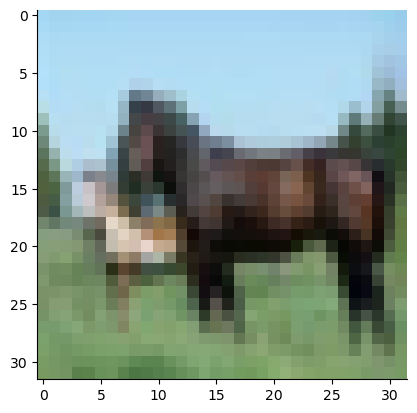

In [14]:
plt.imshow(X[12].T.transpose(1,0))

In [94]:
import numpy as np
import torch
from torch.utils.data import Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

def load_cifar10(root="./data_cifar10"):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)) 
    ])

    train_dataset = datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root=root, train=False, download=True, transform=transform)

    X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
    y_train = torch.tensor(train_dataset.targets)
    X_test = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
    y_test = torch.tensor(test_dataset.targets)

    X = torch.cat([X_train, X_test], dim=0)
    y = torch.cat([y_train, y_test], dim=0)
    return X, y

def cifar10_label_skew(
    n_clients=10,
    n_samples=10,
    n_samples_val=500,
    alpha=1,
    seed=42,
):
    """
    Split CIFAR-10 training dataset into client-specific subsets
    using Dirichlet label skew.
    """
    rng = np.random.default_rng(seed)
    X, y = load_cifar10()

    # Extract labels
    y = np.array(y)
    n_classes = len(np.unique(y))

    # Group indices by class
    indices_by_class = {k: np.where(y == k)[0] for k in range(n_classes)}

    # Shuffle indices within each class
    for idxs in indices_by_class.values():
        rng.shuffle(idxs)

    for _ in range(20):  # attempt up to 20 times
        client_indices = [[] for _ in range(n_clients)]
        label_counts = np.zeros((n_clients, n_classes))

        # Distribute each class across clients
        for k in range(n_classes):
            idxs = indices_by_class[k]
            proportions = rng.dirichlet([alpha] * n_clients)

            split_points = (np.cumsum(proportions) * len(idxs)).astype(int)[:-1]
            split_idxs = np.split(idxs, split_points)

            for client_id, idx_set in enumerate(split_idxs):
                client_indices[client_id].extend(idx_set.tolist())
                label_counts[client_id, k] = len(idx_set)

        # Ensure minimum samples per client
        if all(len(idxs) >= n_samples + n_samples_val for idxs in client_indices):
            break
    else:
        raise ValueError("Failed to generate valid client splits after 20 attempts.")

    # Normalize label proportions
    label_proportions = label_counts / label_counts.sum(axis=1, keepdims=True)

    # ------------------------------------------------------------------
    # Create per-client train/val subsets
    # ------------------------------------------------------------------
    # Allocate train/val per client
    X_train = torch.zeros((n_clients, n_samples, *X.shape[1:]), dtype=torch.float32)
    y_train = torch.zeros((n_clients, n_samples), dtype=torch.long)
    X_val = torch.zeros((n_clients, n_samples_val, *X.shape[1:]), dtype=torch.float32)
    y_val = torch.zeros((n_clients, n_samples_val), dtype=torch.long)
    
    for i, idxs in enumerate(client_indices):
        X_t, X_v, y_t, y_v = train_test_split(X[idxs], y[idxs], test_size=n_samples_val, stratify=y[idxs], random_state=seed)

        X_train[i] = X_t[:n_samples]
        y_train[i] = torch.tensor(y_t)[:n_samples]
        X_val[i] = X_v      
        y_val[i] = torch.tensor(y_v)

    return {
        "train": (X_train, y_train),
        "val": (X_val, y_val)
    }

In [35]:
import numpy as np

def print_client_statistics(client_subsets, n_classes=10):
    """
    Print per-client statistics for a list of Subsets built from (X, y) tuples.
    
    Args:
        client_subsets: list of Subset objects
        n_classes: number of classes
    """
    # Header
    header = ["Client"] + [f"Class {c}" for c in range(n_classes)] + ["Total"]
    print("\t".join(header))
    
    for i, subset in enumerate(client_subsets):
        # For tuple (X, y), dataset[1] contains labels
        labels = np.array([subset.dataset[1][idx] for idx in subset.indices])
        class_counts = [np.sum(labels == c) for c in range(n_classes)]
        total = len(labels)
        row = [str(i)] + [str(count) for count in class_counts] + [str(total)]
        print("\t".join(row))

In [39]:
print_client_statistics(client_train_datasets, n_classes=10)

Client	Class 0	Class 1	Class 2	Class 3	Class 4	Class 5	Class 6	Class 7	Class 8	Class 9	Total
0	1	3	0	0	7	2	5	2	0	0	20
1	4	0	0	5	1	0	4	3	2	1	20
2	0	3	0	1	5	1	2	2	4	2	20
3	0	0	3	1	2	2	6	3	0	3	20
4	5	1	3	1	1	0	4	0	1	4	20
5	3	5	1	1	0	1	0	2	4	3	20
6	3	0	5	3	5	1	0	0	1	2	20
7	1	3	3	0	6	0	0	4	3	0	20
8	3	1	5	0	1	3	5	1	1	0	20
9	1	0	0	11	0	4	0	1	1	2	20


In [40]:
print_client_statistics(client_val_datasets, n_classes=10)

Client	Class 0	Class 1	Class 2	Class 3	Class 4	Class 5	Class 6	Class 7	Class 8	Class 9	Total
0	21	42	11	41	129	115	112	8	1	20	500
1	40	1	24	67	15	1	178	132	37	5	500
2	52	57	2	5	76	119	6	48	61	74	500
3	19	0	35	18	52	25	144	95	15	97	500
4	81	58	56	45	26	1	73	19	10	131	500
5	84	125	13	27	4	26	10	13	147	51	500
6	70	2	141	110	65	13	11	10	13	65	500
7	66	58	41	2	108	36	23	121	45	0	500
8	45	44	172	2	26	81	62	40	22	6	500
9	13	8	0	188	1	81	8	40	74	87	500


In [95]:
client_train_datasets, client_val_datasets = cifar10_label_skew(
    n_clients=10,
    n_samples=100,
    n_samples_val=500,
    alpha=1,
    seed=42,
)

plot_label_distribution_scatter(label_proportions)

Files already downloaded and verified
Files already downloaded and verified


ValueError: not enough values to unpack (expected 3, got 2)

In [101]:
client_train_datasets, client_val_datasets, label_proportions, cluster_assignments = cifar10_split(
    (X,y),
    n_clients = 100,
    n_clusters = 5,
    n_samples = 500,
    n_samples_val = 100,
    alpha = 0.3,          # Dirichlet parameter for label skew
    feature_shift_scale = 0.05, # Brightness / noise scale
    seed = 42
)

In [78]:
def plot_label_distribution_scatter(label_proportions, scale=1000):
    """
    Plots a scatter plot (bubble plot) of digit distributions per client.
    
    Parameters
    ----------
    label_proportions : ndarray, shape (n_clients, 10)
        Each row represents a client and each column a digit (0–9). Values
        are the proportions (or counts) of a given digit for that client.
    scale : float, optional
        A scaling factor to adjust the marker sizes.
    """
    n_clients, n_labels = label_proportions.shape
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Choose a color map that can differentiate 10 categories
    # cmap = plt.get_cmap("tab10")
    digit_palette = {
    0: "#003f5c",  # Deep navy (matches GraphFed-EM family)
    1: "#2f4b7c",  # Slightly lighter navy-blue
    2: "#665191",  # Purple (ties with Oracle Aggr)
    3: "#a05195",  # Magenta-purple
    4: "#d45087",  # Pinkish red (bridges to Oracle Pool)
    5: "#f95d6a",  # Warm red
    6: "#ff7c43",  # Orange (matches Local)
    7: "#ffa600",  # Yellow-orange
    8: "#7aa926",  # Fresh green (ties with Centralized)
    9: "#2ca02c",  # Strong green (Centralized main)
}
    
    for client in range(n_clients):
        for digit in range(n_labels):
            proportion = label_proportions[client, digit]
            size = proportion * scale  # Adjust the bubble size by the scaling factor
            ax.scatter(client, digit, s=size, color=digit_palette[digit], alpha=0.7,
                       edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel("Client ID", fontsize=18)
    ax.set_ylabel("Digit", fontsize=18)
    ax.set_title("Label distribution per client", fontsize=18)
    ax.set_xticks(np.arange(n_clients))
    ax.set_yticks(np.arange(n_labels))
    ax.grid(False)
    plt.tight_layout()
    # plt.savefig("figs/MNIST_labels.pdf", bbox_inches="tight", dpi=300)
    plt.show()

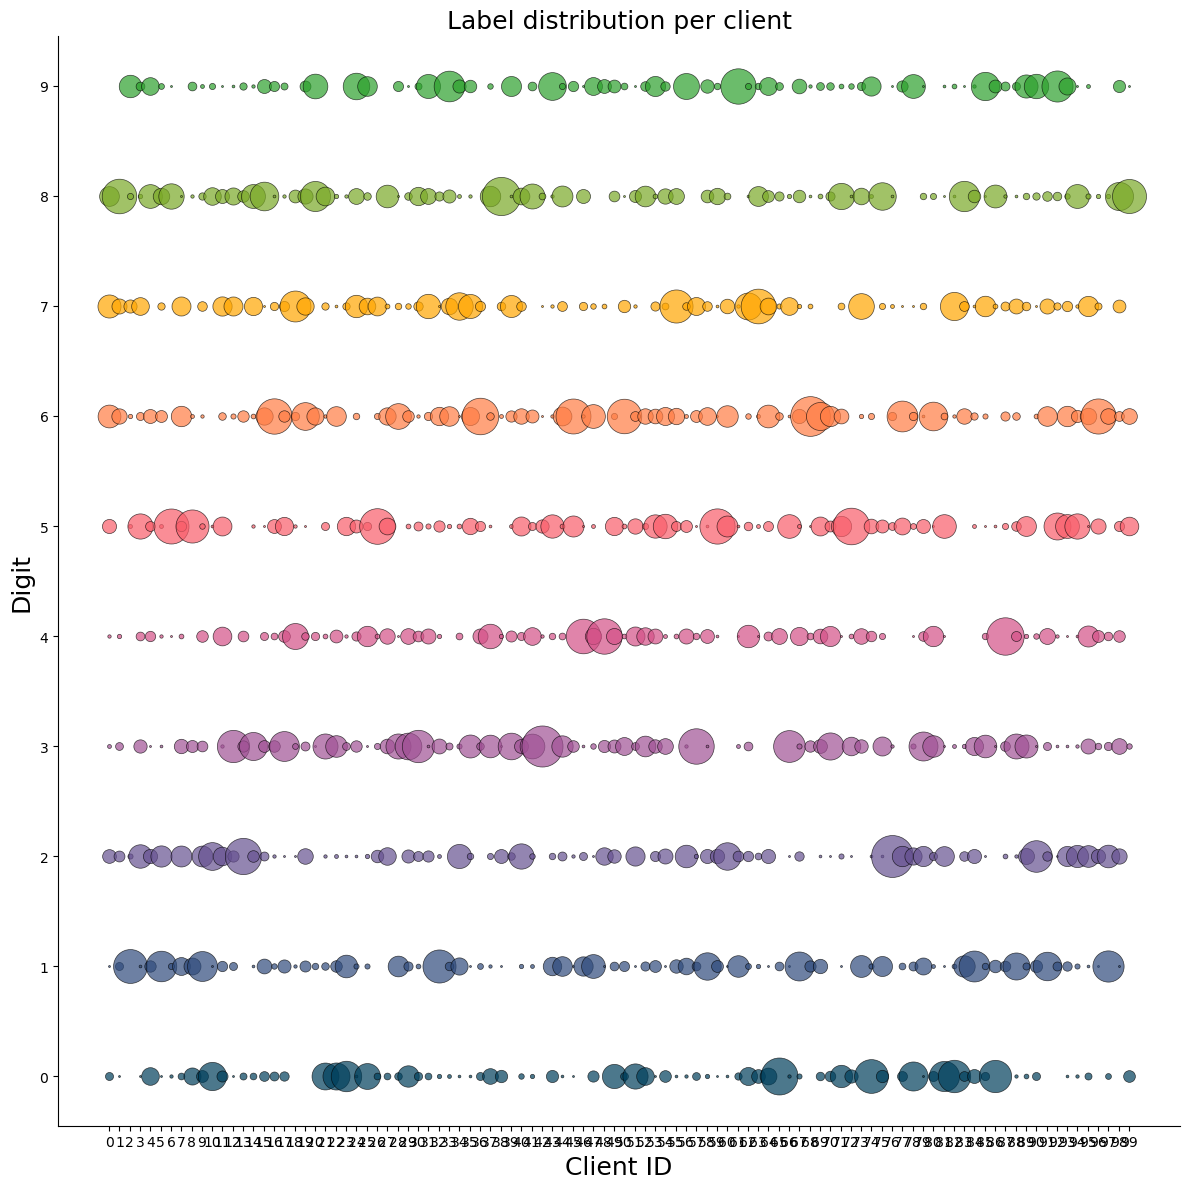

In [106]:
plot_label_distribution_scatter(label_proportions)

In [46]:
import numpy as np
import torch
from torch.utils.data import Subset
from torchvision import datasets, transforms

def load_cifar10(root="./data_cifar10"):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)) 
    ])
    
    train_dataset = datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root=root, train=False, download=True, transform=transform)

    X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
    y_train = torch.tensor(train_dataset.targets)
       
    X_test = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
    y_test = torch.tensor(test_dataset.targets)

    X = torch.cat([X_train, X_test], dim=0)
    y = torch.cat([y_train, y_test], dim=0)
    return X, y

def generate_clustered_cifar10_overlap(
    n_clusters, n_clients, n_samples, n_samples_val, classes_per_cluster=3, seed=0
):
    """
    CIFAR-10 clustered dataset generator with overlapping classes.
    
    Each client belongs to a cluster. Each cluster is assigned a subset of classes (possibly overlapping).
    Each client gets n_samples train and n_samples_val validation examples from its cluster's classes.
    
    Returns:
        dict with keys:
            "train": (X_train, y_train) -- torch tensors of shape (n_clients, n_samples, C,H,W)
            "val":   (X_val, y_val)     -- torch tensors of shape (n_clients, n_samples_val, C,H,W)
            "cluster_labels": list of length n_clients
            "cluster_classes": list of classes per cluster
    """
    rng = np.random.default_rng(seed)
    X, y = load_cifar10()
    y = np.array(y)
    n_classes = 10

    # Assign classes to clusters (allow overlap)
    cluster_classes = []
    for _ in range(n_clusters):
        classes = rng.choice(n_classes, size=classes_per_cluster, replace=False)
        cluster_classes.append(classes.tolist())
    print(cluster_classes)
    # Assign clients to clusters
    clients_per_cluster = n_clients // n_clusters
    cluster_labels = []
    for cluster_id in range(n_clusters):
        print("[cluster_id] * clients_per_cluster", [cluster_id] * clients_per_cluster)
        cluster_labels += [cluster_id] * clients_per_cluster
    print(cluster_labels)
    cluster_labels += rng.choice(n_clusters, n_clients - len(cluster_labels)).tolist()
    print(rng.integers(0, n_clusters, size=n_clients))
    cluster_labels = np.array(cluster_labels)
    rng.shuffle(cluster_labels)

    # Prepare per-class indices
    indices_by_class = {c: np.where(y == c)[0].tolist() for c in range(n_classes)}
    for idxs in indices_by_class.values():
        rng.shuffle(idxs)

    # Allocate train/val per client
    X_train = torch.zeros((n_clients, n_samples, *X.shape[1:]), dtype=torch.float32)
    y_train = torch.zeros((n_clients, n_samples), dtype=torch.long)
    X_val = torch.zeros((n_clients, n_samples_val, *X.shape[1:]), dtype=torch.float32)
    y_val = torch.zeros((n_clients, n_samples_val), dtype=torch.long)

    samples_per_class = (n_samples + n_samples_val) // classes_per_cluster
    
    print(cluster_labels)
    for i, cluster_id in enumerate(cluster_labels):
        classes = cluster_classes[cluster_id]
        print("cluster_id, classes", cluster_id, classes)
        client_indices = []

        # Collect samples from cluster's classes
        for c in classes:
            idxs_c = indices_by_class[c]
            take = min(len(idxs_c[:samples_per_class]), n_samples + n_samples_val - len(client_indices))
            client_indices += idxs_c[:take]
            indices_by_class[c] = idxs_c[take:]

        rng.shuffle(client_indices)
        # If not enough samples, sample with replacement from cluster's classes
        while len(client_indices) < n_samples + n_samples_val:
            c = rng.choice(classes)
            idxs_c = np.where(y == c)[0].tolist()
            client_indices.append(rng.choice(idxs_c))

        train_idxs = client_indices[:n_samples]
        val_idxs = client_indices[n_samples:n_samples + n_samples_val]

        X_train[i] = X[train_idxs]
        y_train[i] = torch.tensor(y[train_idxs])
        X_val[i] = X[val_idxs]
        y_val[i] = torch.tensor(y[val_idxs])

    return {
        "train": (X_train, y_train),
        "val": (X_val, y_val),
        "cluster_labels": cluster_labels.tolist(),
        "cluster_classes": cluster_classes
    }

# ----------------------
# Example usage
# ----------------------
dataset = generate_clustered_cifar10_overlap(
    n_clusters=3,
    n_clients=10,
    n_samples=100,
    n_samples_val=1000,
    classes_per_cluster=4,
    seed=42
)

print("Train shape:", dataset["train"][0].shape)
print("Val shape:", dataset["val"][0].shape)
print("Cluster classes:", dataset["cluster_classes"])
print("Cluster labels per client:", dataset["cluster_labels"][:10])

Files already downloaded and verified
Files already downloaded and verified
[[4, 0, 5, 6], [4, 1, 0, 5], [5, 4, 6, 1]]
[cluster_id] * clients_per_cluster [0, 0, 0]
[cluster_id] * clients_per_cluster [1, 1, 1]
[cluster_id] * clients_per_cluster [2, 2, 2]
[0, 0, 0, 1, 1, 1, 2, 2, 2]
[0 2 2 1 1 2 1 1 1 0]
[2 1 0 1 1 0 2 2 1 0]
cluster_id, classes 2 [5, 4, 6, 1]
cluster_id, classes 1 [4, 1, 0, 5]
cluster_id, classes 0 [4, 0, 5, 6]
cluster_id, classes 1 [4, 1, 0, 5]
cluster_id, classes 1 [4, 1, 0, 5]
cluster_id, classes 0 [4, 0, 5, 6]
cluster_id, classes 2 [5, 4, 6, 1]
cluster_id, classes 2 [5, 4, 6, 1]
cluster_id, classes 1 [4, 1, 0, 5]
cluster_id, classes 0 [4, 0, 5, 6]
Train shape: torch.Size([10, 100, 3, 32, 32])
Val shape: torch.Size([10, 1000, 3, 32, 32])
Cluster classes: [[4, 0, 5, 6], [4, 1, 0, 5], [5, 4, 6, 1]]
Cluster labels per client: [2, 1, 0, 1, 1, 0, 2, 2, 1, 0]


In [24]:
dataset["train"][0].min(), dataset["train"][0].max(), dataset["train"][0].mean()

(tensor(-1.9895), tensor(2.1265), tensor(-0.0033))

In [50]:
dataset["train"][1].shape

torch.Size([10, 100])

In [155]:
import pandas as pd

df0 = pd.read_csv("../results/linear_syn_dm/Algorithm2_SKLearn/dt_synthetic_2_2.csv")
df1 = pd.read_csv("../results/linear_syn_dm/Algorithm2_SKLearn/dt_synthetic_10_0.csv")
df2 = pd.read_csv("../results/linear_syn_dm/Algorithm2_SKLearn/dt_synthetic_10_3.csv")
df3 = pd.read_csv("../results/linear_syn_dm/Algorithm2_SKLearn/dt_synthetic_50_1.csv")

In [62]:
df0

,iter,loss_mean,MSE_val,data_n_clusters,data_n_clients,data_n_samples,data_n_samples_val,data_n_features,data_noise_scale,data_noise_weight,model_max_depth,algo_lmbd,algo_S,algo_R
0,0,0.148685,5.845712,3,150,10,500,2,0,0,5,0.05,30,200
1,1,0.190099,5.440924,3,150,10,500,2,0,0,5,0.05,30,200
2,2,0.200278,5.304354,3,150,10,500,2,0,0,5,0.05,30,200
3,3,0.208454,5.134677,3,150,10,500,2,0,0,5,0.05,30,200
4,4,0.233716,4.841043,3,150,10,500,2,0,0,5,0.05,30,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,0.591717,3.801617,3,150,10,500,2,0,0,5,0.05,30,200
196,196,0.563322,3.779158,3,150,10,500,2,0,0,5,0.05,30,200
197,197,0.561170,3.801094,3,150,10,500,2,0,0,5,0.05,30,200
198,198,0.563794,3.847883,3,150,10,500,2,0,0,5,0.05,30,200


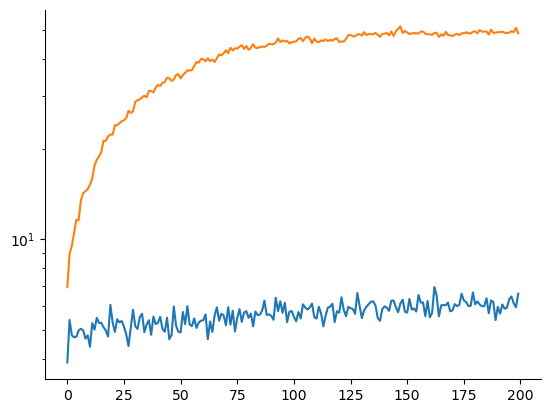

In [160]:
# plt.plot(df0["loss_mean"])
plt.plot(df1["loss_mean"])
plt.plot(df2["loss_mean"])
# plt.plot(df3["loss_mean"])
plt.yscale('log')

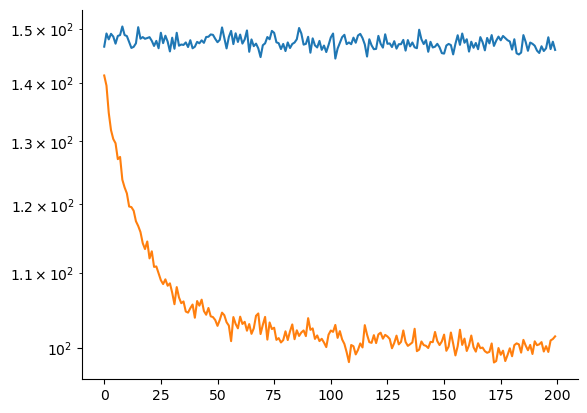

In [158]:
# plt.plot(df0["MSE_val"])
plt.plot(df1["MSE_val"])
plt.plot(df2["MSE_val"])
# plt.plot(df3["MSE_val"])
plt.yscale('log')

(0.0, 5.0)

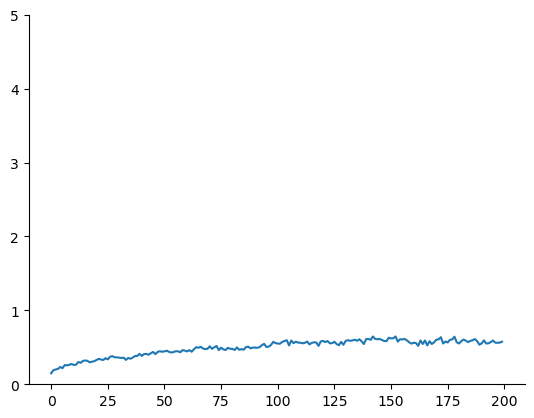

In [117]:
plt.plot(df0["loss_mean"])
plt.plot(df1["loss_mean"])
plt.ylim(0,5)

In [110]:
def generate_rotated_cifar10(n_clusters=4, n_clients=100, seed=0):
    """
    Generate rotated CIFAR dataset partitioned into clusters by rotation.

    Args:
        n_clusters (int): Number of rotation clusters
        n_clients (int): Number of clients
        seed (int): Random seed for reproducibility

    Returns:
        dict with keys:
            "train": (X_train, y_train) -- torch tensors (n_clients, n_samples, C,H,W)
            "val":   (X_val, y_val)     -- torch tensors (n_clients, n_samples_val, C,H,W)
            "cluster_labels": list of length n_clients
            "cluster_rotations": list of rotations per cluster
    """
    rng = np.random.default_rng(seed)

    base_train = datasets.CIFAR10(
        root="./data_cifar10", train=True, download=True, transform=transforms.ToTensor()
    )
    base_test = datasets.CIFAR10(
        root="./data_cifar10", train=False, download=True, transform=transforms.ToTensor()
    )

    rotations_all = [0, 90, 180, 270]
    assert n_clusters <= len(rotations_all), "n_clusters cannot exceed number of available rotations"
    rotations = rotations_all[:n_clusters]

    # Convert to tensors
    X_base_train = torch.stack([t[0] for t in base_train])
    y_base_train = torch.tensor([t[1] for t in base_train])
    X_base_test = torch.stack([t[0] for t in base_test])
    y_base_test = torch.tensor([t[1] for t in base_test])

    # Calculate samples per client
    n_clients_per_cluster = n_clients // n_clusters
    
    n_samples_per_client = X_base_train.shape[0] // n_clients_per_cluster
    n_samples_val_per_client = X_base_test.shape[0] // n_clients_per_cluster
    print(n_clients_per_cluster, n_samples_per_client, n_samples_val_per_client)

    X_train = torch.zeros((n_clients, n_samples_per_client, *X_base_train.shape[1:]))
    y_train = torch.zeros((n_clients, n_samples_per_client), dtype=torch.long)
    X_val = torch.zeros((n_clients, n_samples_val_per_client, *X_base_test.shape[1:]))
    y_val = torch.zeros((n_clients, n_samples_val_per_client), dtype=torch.long)

    cluster_labels = np.zeros(n_clients, dtype=int)

    # Generate rotated datasets for each cluster
    client_idx = 0
    for cluster_id, angle in enumerate(rotations):
        transform_rot = transforms.Lambda(lambda x: transforms.functional.rotate(x, angle))
        X_train_rot = torch.stack([transform_rot(img) for img in X_base_train])
        X_val_rot = torch.stack([transform_rot(img) for img in X_base_test])

        # Shuffle indices
        train_indices = rng.permutation(X_train_rot.shape[0])
        val_indices = rng.permutation(X_val_rot.shape[0])

        # Split data among clients assigned to this cluster
        for i in range(n_clients_per_cluster):
            start = i * n_samples_per_client
            end = i * n_samples_per_client + n_samples_per_client
            
            X_train[client_idx] = X_train_rot[train_indices[start:end]]
            y_train[client_idx] = y_base_train[train_indices[start:end]]

            start = i * n_samples_val_per_client
            end = i * n_samples_val_per_client + n_samples_val_per_client
            
            X_val[client_idx] = X_val_rot[val_indices[start:end]]
            y_val[client_idx] = y_base_test[val_indices[start:end]]

            cluster_labels[client_idx] = cluster_id
            client_idx += 1

    return {
        "train": (X_train, y_train),
        "val": (X_val, y_val),
        "cluster_labels": cluster_labels.tolist(),
        "cluster_rotations": rotations
    }

In [113]:
generate_rotated_cifar10(n_clusters=2, n_clients=200)

Files already downloaded and verified
Files already downloaded and verified
100 500 100


{'train': (tensor([[[[[0.6667, 0.6863, 0.7020,  ..., 0.6549, 0.6196, 0.5961],
             [0.5529, 0.5608, 0.5765,  ..., 0.6392, 0.5843, 0.5686],
             [0.5843, 0.5647, 0.5490,  ..., 0.6549, 0.6235, 0.5608],
             ...,
             [0.7137, 0.6392, 0.5882,  ..., 0.5373, 0.5412, 0.5294],
             [0.5961, 0.5294, 0.5059,  ..., 0.4314, 0.4275, 0.4392],
             [0.5882, 0.5333, 0.5137,  ..., 0.4314, 0.4314, 0.4392]],
  
            [[0.3804, 0.3922, 0.4039,  ..., 0.4000, 0.4275, 0.4392],
             [0.3490, 0.3451, 0.3490,  ..., 0.5176, 0.4784, 0.4235],
             [0.4667, 0.4314, 0.4000,  ..., 0.6275, 0.5725, 0.4353],
             ...,
             [0.7176, 0.6275, 0.5882,  ..., 0.5725, 0.5843, 0.5686],
             [0.6000, 0.5373, 0.5098,  ..., 0.4824, 0.4745, 0.4863],
             [0.5922, 0.5412, 0.5176,  ..., 0.4784, 0.4784, 0.4863]],
  
            [[0.3294, 0.3490, 0.3647,  ..., 0.3922, 0.3961, 0.3647],
             [0.3059, 0.3098, 0.3176,  ..., 0.5333